In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import numpy.typing as npt
import matplotlib.pyplot as plt
from IPython.display import Video
from scipy.spatial.transform import Rotation

from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
import seaborn as sb
import itertools


import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

#plt.style.use("seaborn-deep")

sb.set_palette("husl",3)
sb.set_style("whitegrid")

2024-02-26 16:44:26.394439: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-26 16:44:26.502766: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-02-26 16:44:26.502787: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-02-26 16:44:27.029193: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2024-

In [2]:
PATH_TO_EXERCISE_FOLDER = "Exercises/front_raise/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)


['Exercises/front_raise/front_raise1.csv', 'Exercises/front_raise/front_raise10.csv', 'Exercises/front_raise/front_raise11.csv', 'Exercises/front_raise/front_raise12.csv', 'Exercises/front_raise/front_raise13.csv', 'Exercises/front_raise/front_raise14.csv', 'Exercises/front_raise/front_raise15.csv', 'Exercises/front_raise/front_raise16.csv', 'Exercises/front_raise/front_raise17.csv', 'Exercises/front_raise/front_raise18.csv', 'Exercises/front_raise/front_raise19.csv', 'Exercises/front_raise/front_raise2.csv', 'Exercises/front_raise/front_raise20.csv', 'Exercises/front_raise/front_raise3.csv', 'Exercises/front_raise/front_raise4.csv', 'Exercises/front_raise/front_raise5.csv', 'Exercises/front_raise/front_raise6.csv', 'Exercises/front_raise/front_raise7.csv', 'Exercises/front_raise/front_raise8.csv', 'Exercises/front_raise/front_raise9.csv']


In [3]:
def load_and_label_data(file_paths, label):
    """Load data from multiple CSV files and assign a label."""
    data_list = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        # The CSV contains 'ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3'
        df['label'] = label
        data_list.append(df)
    return pd.concat(data_list)

In [4]:
completedf_front_raise = load_and_label_data(excersise_files, 'front_raise')

In [5]:
completedf_front_raise

,ax,ay,az,q0,q1,q2,q3,label
0,8272.0,-1434.0,1282.0,0.343,-0.629,-0.196,-0.669,front_raise
1,8712.0,-1518.0,1006.0,0.341,-0.630,-0.192,-0.670,front_raise
2,9318.0,-1464.0,1060.0,0.339,-0.632,-0.187,-0.671,front_raise
3,9922.0,-1780.0,1040.0,0.338,-0.634,-0.182,-0.672,front_raise
4,10366.0,-1970.0,850.0,0.338,-0.635,-0.176,-0.672,front_raise
...,...,...,...,...,...,...,...,...
1824,8700.0,-440.0,896.0,0.498,0.392,-0.553,0.541,front_raise
1825,9612.0,-424.0,1144.0,0.492,0.391,-0.552,0.548,front_raise
1826,10066.0,-78.0,1214.0,0.488,0.389,-0.551,0.554,front_raise
1827,9986.0,-642.0,984.0,0.484,0.387,-0.550,0.560,front_raise


In [6]:
PATH_TO_EXERCISE_FOLDER = "Exercises/shoulder_press/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['Exercises/shoulder_press/shoulder_press1.csv', 'Exercises/shoulder_press/shoulder_press10.csv', 'Exercises/shoulder_press/shoulder_press11.csv', 'Exercises/shoulder_press/shoulder_press12.csv', 'Exercises/shoulder_press/shoulder_press13.csv', 'Exercises/shoulder_press/shoulder_press14.csv', 'Exercises/shoulder_press/shoulder_press15.csv', 'Exercises/shoulder_press/shoulder_press16.csv', 'Exercises/shoulder_press/shoulder_press17.csv', 'Exercises/shoulder_press/shoulder_press18.csv', 'Exercises/shoulder_press/shoulder_press19.csv', 'Exercises/shoulder_press/shoulder_press2.csv', 'Exercises/shoulder_press/shoulder_press20.csv', 'Exercises/shoulder_press/shoulder_press3.csv', 'Exercises/shoulder_press/shoulder_press4.csv', 'Exercises/shoulder_press/shoulder_press5.csv', 'Exercises/shoulder_press/shoulder_press6.csv', 'Exercises/shoulder_press/shoulder_press7.csv', 'Exercises/shoulder_press/shoulder_press8.csv', 'Exercises/shoulder_press/shoulder_press9.csv']


In [7]:
completedf_shoulder_press = load_and_label_data(excersise_files, 'shoulder_press')

In [8]:
completedf_shoulder_press

,ax,ay,az,q0,q1,q2,q3,label
0,190.0,8114.0,482.0,0.725,0.688,-0.034,-0.019,shoulder_press
1,188.0,8190.0,488.0,0.725,0.688,-0.034,-0.019,shoulder_press
2,210.0,8248.0,516.0,0.725,0.688,-0.034,-0.019,shoulder_press
3,212.0,8136.0,426.0,0.725,0.688,-0.034,-0.019,shoulder_press
4,170.0,8150.0,438.0,0.725,0.688,-0.034,-0.019,shoulder_press
...,...,...,...,...,...,...,...,...
1670,-9661.0,-1312.0,-2406.0,0.714,-0.015,0.699,0.030,shoulder_press
1671,-10159.0,-2438.0,-1764.0,0.725,0.005,0.689,0.021,shoulder_press
1672,-8901.0,-2868.0,-2208.0,0.736,0.029,0.677,0.010,shoulder_press
1673,-7483.0,-1260.0,-3020.0,0.746,0.054,0.664,-0.004,shoulder_press


In [9]:
df_concatenated = pd.concat([completedf_front_raise, completedf_shoulder_press], ignore_index=True)

In [10]:
df_concatenated

,ax,ay,az,q0,q1,q2,q3,label
0,8272.0,-1434.0,1282.0,0.343,-0.629,-0.196,-0.669,front_raise
1,8712.0,-1518.0,1006.0,0.341,-0.630,-0.192,-0.670,front_raise
2,9318.0,-1464.0,1060.0,0.339,-0.632,-0.187,-0.671,front_raise
3,9922.0,-1780.0,1040.0,0.338,-0.634,-0.182,-0.672,front_raise
4,10366.0,-1970.0,850.0,0.338,-0.635,-0.176,-0.672,front_raise
...,...,...,...,...,...,...,...,...
83727,-9661.0,-1312.0,-2406.0,0.714,-0.015,0.699,0.030,shoulder_press
83728,-10159.0,-2438.0,-1764.0,0.725,0.005,0.689,0.021,shoulder_press
83729,-8901.0,-2868.0,-2208.0,0.736,0.029,0.677,0.010,shoulder_press
83730,-7483.0,-1260.0,-3020.0,0.746,0.054,0.664,-0.004,shoulder_press


In [11]:
def split_sequences(dataframe, sequence_length):
    """Split the dataframe into sequences of a given length, including all relevant columns."""
    X, y = [], []
    columns_of_interest = ['q0', 'q1', 'q2', 'q3']
    for i in range(0, len(dataframe) - sequence_length + 1, sequence_length):
        sequence = dataframe.iloc[i:i+sequence_length][columns_of_interest]
        label = dataframe.iloc[i]['label']
        X.append(sequence.values)
        y.append(label)
    return np.array(X), np.array(y)

In [25]:
x, y = split_sequences(df_concatenated, 500)

In [26]:
len(x)

167

In [27]:
len(y)

167

In [28]:
len(x[0])

500

In [29]:
y[1]

'front_raise'

In [30]:
x.shape

(167, 500, 4)

### Model Train

In [53]:
X_train_val, X_val, y_train_val, y_val = train_test_split(x, y, test_size=0.1)
X_train, X_test, y_train, y_test = train_test_split(X_train_val, y_train_val, test_size=0.1)

In [54]:
len(np.unique(y_train))

2

In [55]:
y_train.shape, X_train.shape

((135,), (135, 500, 4))

In [56]:
class_names = np.unique(y_train)
num_classes = len(np.unique(y_train))
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert text labels into numeric identifiers
y_train_encoded = label_encoder.fit_transform(y_train)

# Convert numeric labels into one-hot
y_train_one_hot = to_categorical(y_train_encoded)


# Convert text labels into numeric identifiers
y_val_encoded = label_encoder.fit_transform(y_val)


# Convert numeric labels into one-hot
y_val_one_hot = to_categorical(y_val_encoded)

# Convert text labels into numeric identifiers
y_test_encoded = label_encoder.fit_transform(y_test)

# Convert numeric labels into one-hot
y_test_one_hot = to_categorical(y_test_encoded)

In [57]:
# Define the model
inputs = tf.keras.Input(shape=(500, 4))

# Apply Dense layers to the inputs
layer = keras.layers.Dense(128, activation=tf.nn.relu6)(inputs)
layer = keras.layers.Dropout(0.5)(layer)
layer = keras.layers.Dense(64, activation=tf.nn.relu6)(layer)
layer = keras.layers.Dropout(0.5)(layer)

# Add GlobalAveragePooling1D to reduce dimensionality
layer = keras.layers.GlobalAveragePooling1D()(layer)

# Final layer for classification
outputs = keras.layers.Dense(len(np.unique(y_train)), activation="softmax")(layer)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 500, 4)]          0         
                                                                 
 dense_12 (Dense)            (None, 500, 128)          640       
                                                                 
 dropout_8 (Dropout)         (None, 500, 128)          0         
                                                                 
 dense_13 (Dense)            (None, 500, 64)           8256      
                                                                 
 dropout_9 (Dropout)         (None, 500, 64)           0         
                                                                 
 global_average_pooling1d_4   (None, 64)               0         
 (GlobalAveragePooling1D)                                        
                                                           

In [58]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
checkpoint_path = "weights.best.hdf5"
checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', 
                                              patience=50)

# Start training
print(X_train.shape)
history = model.fit(X_train, y_train_one_hot,
                    epochs=200,
                    batch_size=16,
                    validation_data=(X_val, y_val_one_hot),
                    callbacks=[checkpoint, earlystopping],
                    )# class_weight=class_weights

(135, 500, 4)
Epoch 1/200
8/9 [=========================>....] - ETA: 0s - loss: 0.6644 - accuracy: 0.6562
Epoch 1: val_accuracy improved from -inf to 0.82353, saving model to weights.best.hdf5
9/9 [==============================] - 1s 24ms/step - loss: 0.6623 - accuracy: 0.6667 - val_loss: 0.6054 - val_accuracy: 0.8235
Epoch 2/200
7/9 [======================>.......] - ETA: 0s - loss: 0.5658 - accuracy: 0.9018
Epoch 2: val_accuracy did not improve from 0.82353
9/9 [==============================] - 0s 12ms/step - loss: 0.5584 - accuracy: 0.9185 - val_loss: 0.5172 - val_accuracy: 0.8235
Epoch 3/200
7/9 [======================>.......] - ETA: 0s - loss: 0.4608 - accuracy: 0.9107
Epoch 3: val_accuracy did not improve from 0.82353
9/9 [==============================] - 0s 12ms/step - loss: 0.4517 - accuracy: 0.9111 - val_loss: 0.4421 - val_accuracy: 0.8235
Epoch 4/200
7/9 [======================>.......] - ETA: 0s - loss: 0.3631 - accuracy: 0.9018
Epoch 4: val_accuracy did not improve fro

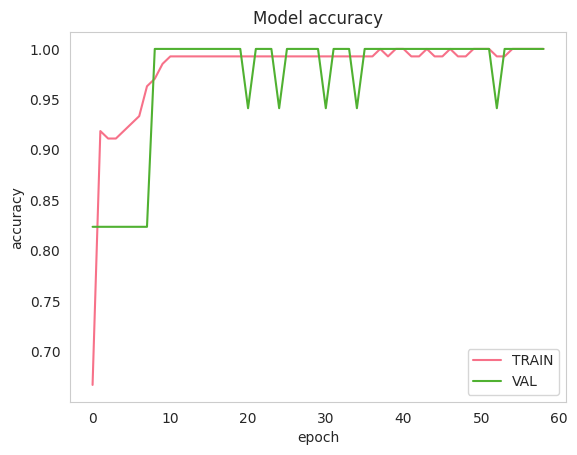

In [59]:
# Visualize the training history to see whether you're overfitting.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['TRAIN', 'VAL'], loc='lower right')
plt.grid()
plt.show()

In [60]:
loss, accuracy = model.evaluate(X_test, y_test_one_hot)

1/1 [==============================] - 0s 18ms/step - loss: 0.0092 - accuracy: 1.0000


1/1 [==============================] - 0s 71ms/step
Confusion matrix, without normalization

Classification Report:
                 precision    recall  f1-score   support

   front_raise       1.00      1.00      1.00         5
shoulder_press       1.00      1.00      1.00        10

      accuracy                           1.00        15
     macro avg       1.00      1.00      1.00        15
  weighted avg       1.00      1.00      1.00        15



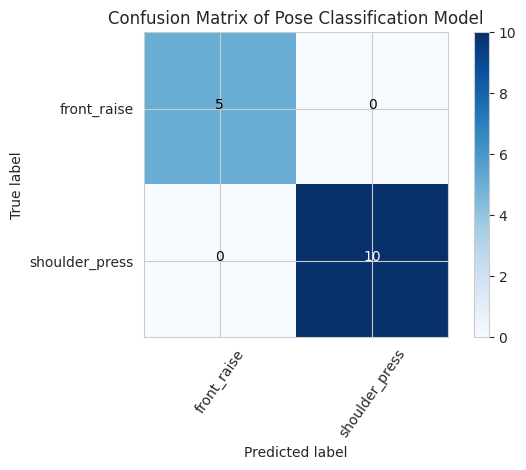

In [61]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """Plots the confusion matrix."""
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=55)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

# Classify pose in the TEST dataset using the trained model
y_pred = model.predict(X_test)

# Convert the prediction result to class name
y_pred_label = [class_names[i] for i in np.argmax(y_pred, axis=1)]
y_true_label = [class_names[i] for i in np.argmax(y_test_one_hot, axis=1)]

# Plot the confusion matrix
cm = confusion_matrix(np.argmax(y_test_one_hot, axis=1), np.argmax(y_pred, axis=1))
plot_confusion_matrix(cm,
                      class_names,
                      title ='Confusion Matrix of Pose Classification Model')

# Print the classification report
print('\nClassification Report:\n', classification_report(y_true_label, y_pred_label))

### Workaround

In [40]:
def buildFullDataFrame(csv_paths, className, debugId = 0):
    completedf = pd.DataFrame(columns=['exercise', 'quaternions'])
    for idx1,file in enumerate(csv_paths):
        df = pd.read_csv(file)
        #print(file)
        # convert rotation matrices to quaternions.
        series = pd.Series(data={'exercise': className, 'quaternions': df.apply(lambda row: [row['q0'], row['q1'], row['q2'], row['q3']], axis=1).tolist()})
        df_temp2= pd.DataFrame([series])
        completedf=pd.concat([completedf, df_temp2], ignore_index=True)
    return completedf

In [41]:
completedf = buildFullDataFrame(excersise_files, className = 'front_raise')
completedf.head()

,exercise,quaternions
0,front_raise,"[[0.343, -0.629, -0.196, -0.669], [0.341, -0.6..."
1,front_raise,"[[0.668, 0.103, -0.695, 0.245], [0.668, 0.104,..."
2,front_raise,"[[0.717, -0.02, -0.678, 0.16], [0.717, -0.019,..."
3,front_raise,"[[0.753, 0.099, -0.644, 0.096], [0.752, 0.1, -..."
4,front_raise,"[[0.738, 0.124, -0.654, 0.114], [0.739, 0.123,..."


In [39]:
gest_id = {'front_raise': 0, 'shoulder_press': 1}
pad_train_df['gesture'] = pad_train_df['gesture'].apply(lambda x: gest_id[x])
pad_test_df['gesture'] = pad_test_df['gesture'].apply(lambda x: gest_id[x])
pad_val_df['gesture'] = pad_val_df['gesture'].apply(lambda x: gest_id[x])

NameError: name 'pad_train_df' is not defined

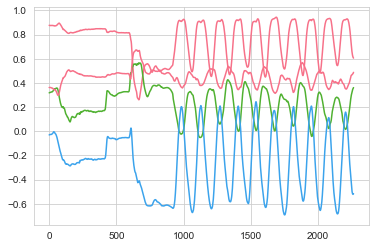

In [55]:
plt.plot(completedf.loc[17]['quaternions'], label=['q0', 'q1', 'q2', 'q3'])

Number of samples: 1711


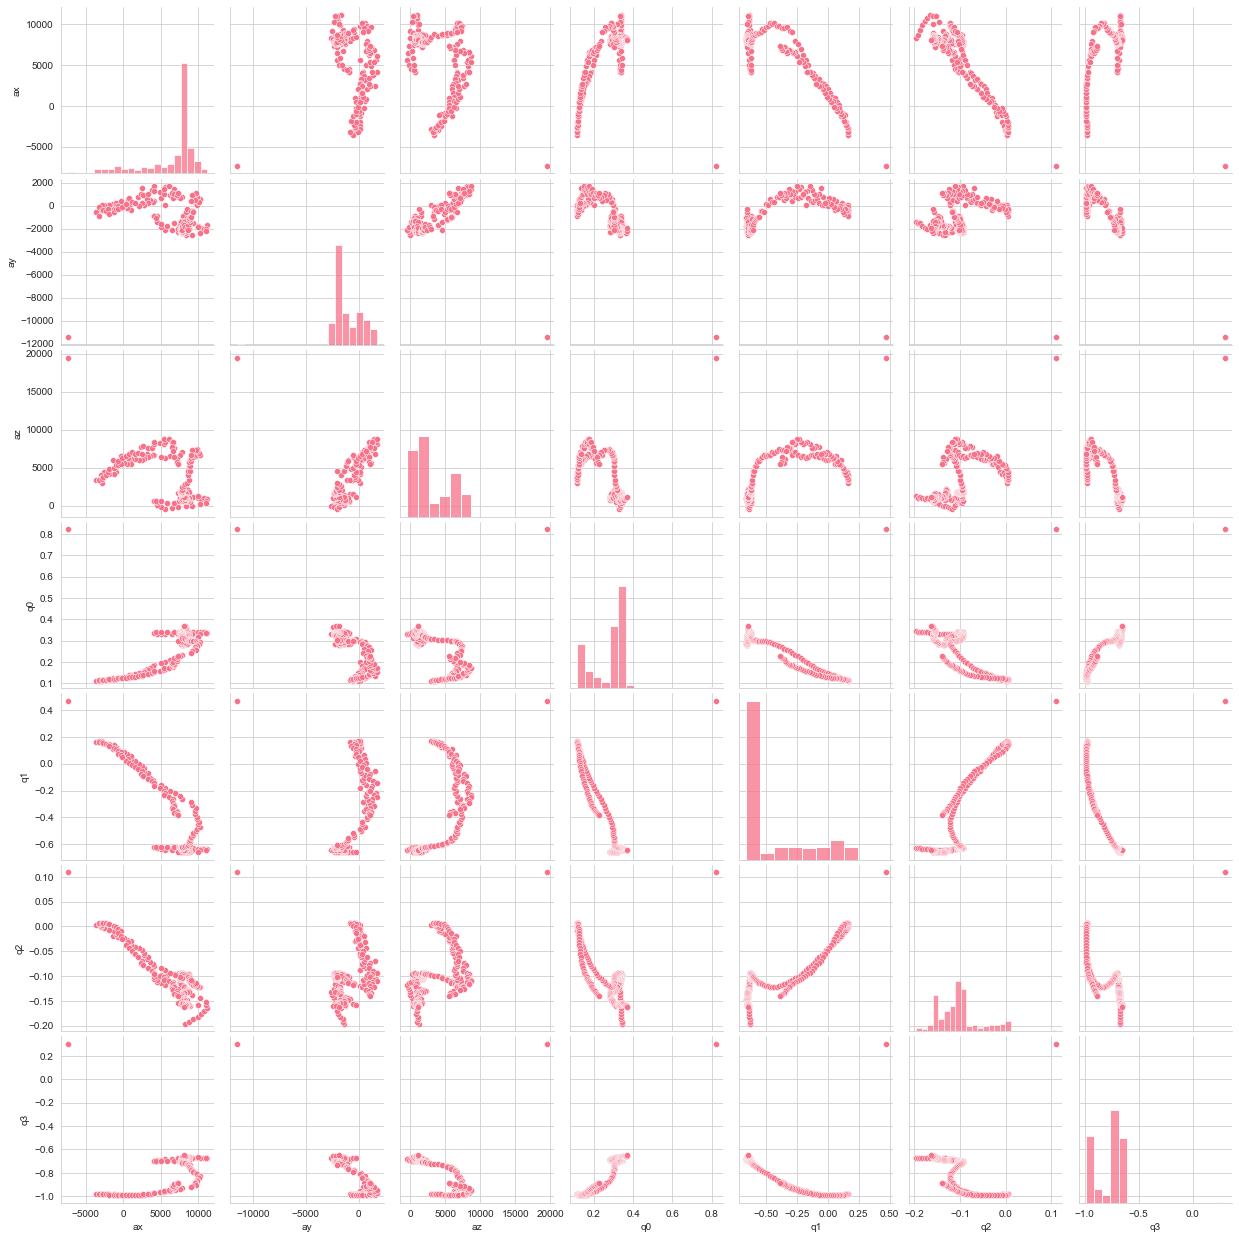

In [38]:
first_pump = pd.read_csv(excersise_list[0])
print('Number of samples: '+ str(len(fist_pump)))
fist_pump_pairplot = sb.pairplot(fist_pump.loc[0:int(len(first_pump) *.15)])

In [39]:
from sklearn import decomposition
from sklearn.decomposition import PCA 



In [42]:
pca_fist = decomposition.PCA()
fist_pump_pca = pca_fist.fit_transform(first_pump[['q0', 'q1', 'q2', 'q3']])
print(pca_fist.explained_variance_ratio_)
fist_comps = pd.DataFrame(pca_fist.components_, columns=['q0', 'q1', 'q2', 'q3'])

[0.94803623 0.0326646  0.01375265 0.00554651]


<AxesSubplot:>

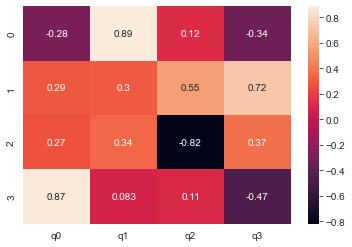

In [43]:
sb.heatmap(fist_comps, annot=True)

In [44]:
print(sum(pca_fist.explained_variance_ratio_[0:4])) #keep roughly 98 percent of the info from our data

1.0000000000000002
